In [ ]:
#1首先提取target_index = ['000300.XSHG','000905.XSHG', '000852.XSHG','932000.INDX','000922.XSHG']的成分股
#index_weights(order_book_id, date=None) 提取全A
#rqdatac.index_weights_ex(order_book_id, date=None, start_date=None, end_date=None, market='cn') 提取其余

#2提取并集的股票行业信息：
#get_instrument_industry(order_book_ids, source='citics_2019', level=1, date=None, market='cn')

#3提取科创板、创业板的成分股ban_index = ["399006.XSHE","000680.XSHG"]
#index_components(order_book_id, date=None, start_date, end_date, market='cn',return_create_tm=False)


In [2]:
import rqdatac
rqdatac.init(
    username = "license",
    password = "ZZ-u7ZWosqrntc3VY3TJzJLPsb-A0o4zehYoiNpDvIBXiwvRIOUmFe7medtMhwu4qiaNxqFSc6ONdGcGeVYgUVd-w5QKScPkmzBEmYVEt94lz9sQZoHwdtQXWWRGGrJqtr7ehiQACydlPS7RcPBfJrpyeTJFsGF1E1guZbpLnvU=XouX9YSi7Pcyo0rSLCMydvHs3nrVq6Rwjda-jI9H_gfGlp53ot0ZnIA6g-ZtvwPDAb62K38pHIqYYyTAyER7FBtZ5HumXzOrWW42LHpUn5-vbnLMxiwbimJ9ns41CaMbjpFEgNcfO52l5wiqDqFCkZNy_OKSDjepfa9GxHsLZZE="
)
from rqdatac import *
import pandas as pd
import numpy as np
import pickle
import os

d:\Ana\envs\rqsdk\lib\site-packages\rqdatac\client.py:263: UserWarning: Your account will be expired after  25 days. Please call us at 0755-22676337 to upgrade or purchase or renew your contract.
  warnings.warn("Your account will be expired after  {} days. "


In [ ]:
# srcdir = "E:/SJTU/实习/国泰海通/barra因子/data_base/index/component"
# df_kj = pd.read_pickle(f"{srcdir}/866011.RI_20_26M_dict.pkl")

# #补齐双板的权重数据
# dates = df_kj.index.get_level_values(0).unique()
# for ban in ['399006.XSHE',"000680.XSHG"]:
#     res_dict = {}
#     for dt in dates:
#         temp = index_weights(ban, dt)
#         res_dict[dt] = temp
#         # 将字典保存为pkl文件
#         pd.to_pickle(res_dict, f"{srcdir}/{ban}_20_26M_weights_dict.pkl")


In [ ]:
#提取全A的复权收益率（月频）
ret_dict = {}
df_kj = pd.read_pickle(f"{srcdir}/866011.RI_20_26M_dict.pkl")
dates = df_kj.keys()
desdir = "E:/SJTU/实习/国泰海通/barra因子/data_base/stk_ret"

for dt in dates:
   stk = df_kj[dt].index.tolist()
   temp = get_price_change_rate(stk, start_date=dt, end_date=dt, expect_df=True, market='cn')
   df_long = temp.stack().to_frame('value')
   df_long.index.names = ['date', 'order_book_id']
   ret_dict[dt] = df_long
   print(dt)
pd.to_pickle(ret_dict,f"{desdir}/全A_ret_dict.pkl")


2020-01-23 00:00:00
2020-02-28 00:00:00
2020-03-31 00:00:00
2020-04-30 00:00:00
2020-05-29 00:00:00
2020-06-30 00:00:00
2020-07-31 00:00:00
2020-08-31 00:00:00
2020-09-30 00:00:00
2020-10-30 00:00:00
2020-11-30 00:00:00
2020-12-31 00:00:00
2021-01-29 00:00:00
2021-02-26 00:00:00
2021-03-31 00:00:00
2021-04-30 00:00:00
2021-05-31 00:00:00
2021-06-30 00:00:00
2021-07-30 00:00:00
2021-08-31 00:00:00
2021-09-30 00:00:00
2021-10-29 00:00:00
2021-11-30 00:00:00
2021-12-31 00:00:00
2022-01-28 00:00:00
2022-02-28 00:00:00
2022-03-31 00:00:00
2022-04-29 00:00:00
2022-05-31 00:00:00
2022-06-30 00:00:00
2022-07-29 00:00:00
2022-08-31 00:00:00
2022-09-30 00:00:00
2022-10-31 00:00:00
2022-11-30 00:00:00
2022-12-30 00:00:00
2023-01-31 00:00:00
2023-02-28 00:00:00
2023-03-31 00:00:00
2023-04-28 00:00:00
2023-05-31 00:00:00
2023-06-30 00:00:00
2023-07-31 00:00:00
2023-08-31 00:00:00
2023-09-28 00:00:00
2023-10-31 00:00:00
2023-11-30 00:00:00
2023-12-29 00:00:00
2024-01-31 00:00:00
2024-02-29 00:00:00


In [ ]:
#提取全A的复权收益率（日频）
from datetime import datetime

srcdir = "E:/SJTU/实习/国泰海通/barra因子/data_base/index_component_日频"
desdir = "E:/SJTU/实习/国泰海通/barra因子/data_base/stk_ret"
df_kj = pd.read_pickle(f"{srcdir}/866011.RI_20_26D_dict.pkl")
start_date = datetime(2024, 1, 1)
end_date = datetime(2026, 3, 25)
# 筛选符合条件的日期
filtered_dates = [date for date in df_kj.keys() if start_date <= date <= end_date]

ret_dict = {}
for dt in filtered_dates:
   stk = df_kj[dt].index.tolist()
   stk =  [stock for stock in stk if not stock.endswith(".BJSE")]
   print(f"开始提取{dt}")
   temp = get_price_change_rate(stk, start_date=dt, end_date=dt, expect_df=True, market='cn')
   df_long = temp.stack().to_frame('value')
   df_long.index.names = ['date', 'order_book_id']
   ret_dict[dt] = df_long

#df_long
pd.to_pickle(ret_dict,f"{desdir}/全A_ret_24_2603D_dict.pkl")

开始提取2024-01-02 00:00:00
开始提取2024-01-03 00:00:00
开始提取2024-01-04 00:00:00
开始提取2024-01-05 00:00:00
开始提取2024-01-08 00:00:00
开始提取2024-01-09 00:00:00
开始提取2024-01-10 00:00:00
开始提取2024-01-11 00:00:00
开始提取2024-01-12 00:00:00
开始提取2024-01-15 00:00:00
开始提取2024-01-16 00:00:00
开始提取2024-01-17 00:00:00
开始提取2024-01-18 00:00:00
开始提取2024-01-19 00:00:00
开始提取2024-01-22 00:00:00
开始提取2024-01-23 00:00:00
开始提取2024-01-24 00:00:00
开始提取2024-01-25 00:00:00
开始提取2024-01-26 00:00:00
开始提取2024-01-29 00:00:00
开始提取2024-01-30 00:00:00
开始提取2024-01-31 00:00:00
开始提取2024-02-01 00:00:00
开始提取2024-02-02 00:00:00
开始提取2024-02-05 00:00:00
开始提取2024-02-06 00:00:00
开始提取2024-02-07 00:00:00
开始提取2024-02-08 00:00:00
开始提取2024-02-19 00:00:00
开始提取2024-02-20 00:00:00
开始提取2024-02-21 00:00:00
开始提取2024-02-22 00:00:00
开始提取2024-02-23 00:00:00
开始提取2024-02-26 00:00:00
开始提取2024-02-27 00:00:00
开始提取2024-02-28 00:00:00
开始提取2024-02-29 00:00:00
开始提取2024-03-01 00:00:00
开始提取2024-03-04 00:00:00
开始提取2024-03-05 00:00:00
开始提取2024-03-06 00:00:00
开始提取2024-03-07 0

In [7]:
#提取指数的日度收益率
from datetime import datetime
desdir = "E:/SJTU/实习/国泰海通/barra因子/data_base/stk_ret"
temp_idx = get_price_change_rate("866011.RI",  start_date=datetime(2024, 1, 1), end_date=datetime(2026, 3, 25), expect_df=True, market='cn')
temp_idx.to_excel(f"{desdir}/866011.RI_ret_24_2603D.xlsx")

In [ ]:
#提取自由流通股本和收盘价，计算自由流通市值
mcp_dict = {}
desdir = "E:/SJTU/实习/国泰海通/barra因子/data_base/stk_mcp"
for dt in filtered_dates:
    stk = df_kj[dt].index.tolist()
    stk =  [stock for stock in stk if not stock.endswith(".BJSE")]
    a = get_shares(stk, start_date=dt, end_date=dt, fields='free_circulation', expect_df=True, market='cn').droplevel(1)
    b = get_price(stk, start_date=dt, end_date=dt, frequency='1d', fields="close", adjust_type='pre', skip_suspended=False, expect_df=True, time_slice=None, market='cn').droplevel(1)
    df = a.merge(b[["close"]],on="order_book_id",how="left")
    df["free_mkp"] = df["free_circulation"]*df["close"]
    mcp_dict[dt] = df
    print(dt)

pd.to_pickle(mcp_dict, f"{desdir}/全A_freemcp_25_26D_dict.pkl")


2025-01-02 00:00:00
2025-01-03 00:00:00
2025-01-06 00:00:00
2025-01-07 00:00:00
2025-01-08 00:00:00
2025-01-09 00:00:00
2025-01-10 00:00:00
2025-01-13 00:00:00
2025-01-14 00:00:00
2025-01-15 00:00:00
2025-01-16 00:00:00
2025-01-17 00:00:00
2025-01-20 00:00:00
2025-01-21 00:00:00
2025-01-22 00:00:00
2025-01-23 00:00:00
2025-01-24 00:00:00
2025-01-27 00:00:00
2025-02-05 00:00:00
2025-02-06 00:00:00
2025-02-07 00:00:00
2025-02-10 00:00:00
2025-02-11 00:00:00
2025-02-12 00:00:00
2025-02-13 00:00:00
2025-02-14 00:00:00
2025-02-17 00:00:00
2025-02-18 00:00:00
2025-02-19 00:00:00
2025-02-20 00:00:00
2025-02-21 00:00:00
2025-02-24 00:00:00
2025-02-25 00:00:00
2025-02-26 00:00:00
2025-02-27 00:00:00
2025-02-28 00:00:00
2025-03-03 00:00:00
2025-03-04 00:00:00
2025-03-05 00:00:00
2025-03-06 00:00:00
2025-03-07 00:00:00
2025-03-10 00:00:00
2025-03-11 00:00:00
2025-03-12 00:00:00
2025-03-13 00:00:00
2025-03-14 00:00:00
2025-03-17 00:00:00
2025-03-18 00:00:00
2025-03-19 00:00:00
2025-03-20 00:00:00


In [ ]:
#提取股票代码对应的名称等信息
srcdir = "E:/SJTU/实习/国泰海通/barra因子/data_base/index/component"
desdir = "E:/SJTU/实习/国泰海通/barra因子/intermedia"
df_kj = pd.read_pickle(f"{srcdir}/866011.RI_20_26M_dict.pkl")
stk = df_kj[pd.Timestamp('2026-03-31 00:00:00')].index
# ✅ 批量提取股票名称（只取 symbol）
res_dict = {s: instruments(s, market='cn').symbol for s in stk}

# ✅ 字典 → 完美转 DataFrame（不报错！）
df = pd.DataFrame(list(res_dict.items()), columns=['stock_code', 'stock_name'])
df.to_excel(f"{desdir}/全A代码_名称.xlsx")


In [2]:
import pandas as pd
desdir = "E:/SJTU/实习/国泰海通/barra因子/result/延迟alpha"
dict_delay = pd.read_pickle(f"{desdir}/ortho_delay_measures_2024_2026_dict.pkl")
#dict_delay[pd.Timestamp("2025-01-02")].to_excel(f"{desdir}/20250102_delay_measures_sample.xlsx")
dict_delay[pd.Timestamp("2025-01-02")]


,D1,D2,D3,D1_orth,D2_orth,D3_orth
order_book_id,,,,,,
000001.XSHE,0.148299,0.103915,0.123683,-91.554057,479.877079,757.402370
000002.XSHE,0.178974,0.142552,0.116088,498.853020,1399.759871,793.190999
000004.XSHE,0.579853,0.396766,0.445861,531.823362,904.010416,720.910702
000006.XSHE,0.475605,0.322469,0.271814,346.246794,768.065329,300.715714
000007.XSHE,0.402592,0.299351,0.156695,573.336091,992.618481,-275.117741
...,...,...,...,...,...,...
688799.XSHG,0.173284,0.131643,0.134166,905.004631,1566.718493,1589.101522
688800.XSHG,0.252503,0.222580,0.088310,-318.570473,1023.186121,-1352.980970
688819.XSHG,0.091926,0.027289,0.029395,-109.274996,-922.616741,-714.563878


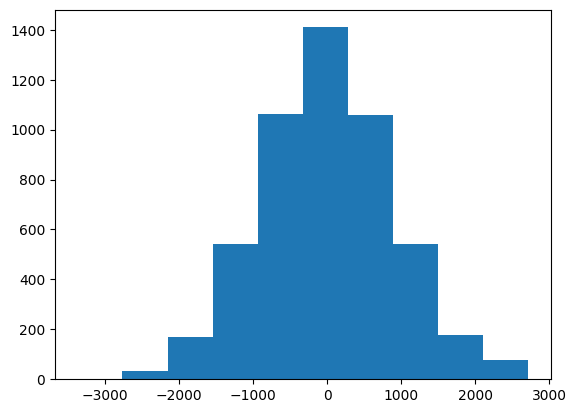

In [5]:
import matplotlib.pyplot as plt
plt.hist(dict_delay[pd.Timestamp("2025-01-02")]["D1_orth"])
plt.show()


In [6]:
desdir = "E:/SJTU/实习/国泰海通/业绩回测/nav"

target = ["000922.XSHG","H00922.INDX"] #红利指数、红利全收益指数
#target = ['000300.XSHG','000905.XSHG', '000852.XSHG','000510.XSHG','932000.INDX']
sd = "20250101"
ed = "20260428"
temp = get_price_change_rate(target, start_date=sd, end_date=ed, expect_df=True, market='cn')
#get_auction_info("000922.XSHG", start_date=sd, end_date=ed, frequency='1d', market='cn') #688012.XSHG
nav = (1 + temp).cumprod()
nav = nav / nav.iloc[0]
nav.to_excel(f"{desdir}/nav_index.xlsx")

In [41]:
import pandas as pd
import numpy as np

srcdir = "E:/SJTU/实习/国泰海通/barra因子/result/管理人暴露/weight_exposure"
df = pd.read_excel(f"{srcdir}/脱敏barra暴露偏离数据2020-2026.xlsx",index_col=0)
df.index = pd.to_datetime(df.index)
df = df[df["基准"]==905]
df

,流动性暴露,杠杆率暴露,残余波动率暴露,盈利率暴露,非线性市值暴露,贝塔暴露,账面市值比暴露,成长性暴露,动量暴露,规模暴露,基准,编码
日期,,,,,,,,,,,,
2025-01-03,-0.0410,0.0664,0.3759,-0.0390,-0.4250,-0.2293,0.1873,-0.3806,0.1924,-0.2743,905,62
2025-01-10,0.3317,-0.0282,0.3457,-0.2752,-0.2491,0.3000,-0.0357,-0.2794,0.3188,-0.2945,905,62
2025-01-17,0.2446,0.0170,0.3279,-0.2321,-0.2891,0.3804,0.0014,-0.2618,0.3844,-0.2952,905,62
2025-01-24,0.2316,0.0037,0.3444,-0.1507,-0.2798,0.3429,0.0141,-0.2564,0.3684,-0.2874,905,62
2025-01-27,0.0743,0.0856,0.2685,-0.0825,-0.3192,0.1215,0.1140,-0.2678,0.0738,-0.2789,905,62
...,...,...,...,...,...,...,...,...,...,...,...,...
2020-12-04,0.0315,-0.1068,0.3690,-0.0449,-0.2247,0.0299,-0.2669,0.1142,0.2371,0.0578,905,49
2020-12-11,0.1424,-0.1293,0.4188,-0.0860,-0.1902,0.0775,-0.2865,0.1100,0.2631,-0.0710,905,49
2020-12-18,0.2250,-0.0474,0.4902,-0.1051,-0.1840,0.1502,-0.2811,0.1452,0.3416,0.0272,905,49


In [42]:
mask = (df["规模暴露"]>0) & (df.index.year==2024) & (df.index.month.isin([1,2,3]))
df_pos = df[mask]
df_pos.groupby("编码").size().sort_values(ascending=False)

编码
160    4
48     1
50     1
56     1
146    1
148    1
187    1
dtype: int64

In [ ]:
df_pos[df_pos["编码"].isin([160,56])]

,流动性暴露,杠杆率暴露,残余波动率暴露,盈利率暴露,非线性市值暴露,贝塔暴露,账面市值比暴露,成长性暴露,动量暴露,规模暴露,基准,编码
日期,,,,,,,,,,,,
2024-03-29,-0.0057,0.0006,-0.0194,-0.0272,-0.0212,0.0259,-0.0177,0.0013,-0.0515,0.0147,905,56
2024-04-12,-0.0230,0.0005,-0.0156,-0.0029,-0.0093,0.0008,0.0072,0.0068,0.0235,0.0069,905,56
2024-04-19,-0.0275,0.0091,0.0471,0.0179,-0.0315,0.0737,0.0159,0.0175,0.0074,0.0275,905,56
2024-03-08,0.0874,0.0660,0.0873,0.1015,0.0320,-0.0185,0.0707,-0.0332,0.0847,0.0351,905,160
2024-03-15,0.0932,0.0681,0.1427,0.0809,0.0596,-0.0297,0.0558,-0.0331,-0.2427,0.0125,905,160
2024-03-22,0.0112,0.0759,0.1155,0.0815,0.0816,-0.0934,0.0606,-0.0375,-0.0304,0.0448,905,160
2024-03-29,-0.0450,0.0598,0.0597,0.0435,0.0692,-0.0766,0.0299,-0.0374,0.0433,0.0262,905,160
2024-04-19,-0.1202,0.0441,0.0284,0.0957,0.0553,0.0219,0.0534,0.0024,0.1326,0.0416,905,160
2024-04-30,-0.0336,-0.0132,-0.0025,0.0504,0.0661,0.0774,0.0093,-0.0145,0.2681,0.0069,905,160


In [ ]:
#提取纯中证500的净值数据
srcdir = "E:/SJTU/实习/国泰海通/barra因子/result/管理人暴露/weight_exposure"
navdir = "E:/SJTU/实习/国泰海通/业绩回测/nav"

nav_df = pd.read_excel(f"{navdir}/中证500净值数据.xlsx",index_col=0)
df = pd.read_excel(f"{srcdir}/脱敏barra暴露偏离数据2020-2026.xlsx",index_col=0)
df = df[df["基准"]==905]
id_500 = df["编码"].unique()
id_500 = sorted(id_500)

nav_lst = []
for id in ["中证500"]+id_500:
    if id in nav_df.columns:
        nav_lst.append(nav_df[id])
    else:
        continue
select_df = pd.concat(nav_lst,axis=1)
select_df.index= pd.to_datetime(select_df.index)
select_df.to_excel(f"{navdir}/纯中证500净值数据.xlsx")


In [38]:
#紧接着查看在2024年1~3月和2025年8~9月的净值数据
import pandas as pd
import numpy as np

# 假设你的数据在 select_df 中，且 index 为 DatetimeIndex
# 先确保 index 是 DatetimeIndex（如果不是的话）
select_df.index = pd.to_datetime(select_df.index)

# ---------------------- 1. 定义两个时间区间 ----------------------
# 区间1：2024年1~3月
mask_2024 = (select_df.index.year == 2024) & (select_df.index.month.isin([1,2,3]))
df_2024 = select_df.loc[mask_2024]

mask_2024y = (select_df.index.year == 2024) 
df_2024y = select_df.loc[mask_2024y]

# 区间2：2025年8~9月
mask_2025 = (select_df.index.year == 2025) & (select_df.index.month.isin([8,9]))
df_2025 = select_df.loc[mask_2025]

mask_2025y = (select_df.index.year == 2025) 
df_2025y = select_df.loc[mask_2025y]    

# ---------------------- 2. 定义计算单区间收益和占比的函数 ----------------------
def calc_win_rate(df_period):
    """
    输入：区间内的净值数据
    输出：该区间内：有效基金数、收益>0的基金数、正收益占比
    """
    # 只保留区间内没有缺失值的列（基金）
    df_clean = df_period.dropna(axis=1, how='any')
    
    if df_clean.empty:
        return 0, 0, 0.0  # 没有有效数据，直接返回0
    
    # 期初净值（区间第一个交易日）
    start_nav = df_clean.iloc[0]
    # 期末净值（区间最后一个交易日）
    end_nav = df_clean.iloc[-1]
    
    # 计算累计收益率
    ret = end_nav / start_nav - 1
    
    # 统计正收益的数量
    win_count = (ret > 0).sum()
    total_count = len(ret)
    win_rate = win_count / total_count if total_count > 0 else 0.0
    
    return total_count, win_count, win_rate, ret

# ---------------------- 3. 分别计算两个区间的结果 ----------------------
print("===== 2024年1~3月 结果 =====")
count_2024, win_2024, rate_2024,ret_2024 = calc_win_rate(df_2024)
print(f"有效基金数: {count_2024}")
print(f"正收益基金数: {win_2024}")
print(f"正收益占比: {rate_2024:.2%}\n")

print("===== 2024年 结果 =====")
count_2024, win_2024, rate_2024,ret_2024y = calc_win_rate(df_2024y)
print(f"有效基金数: {count_2024}")
print(f"正收益基金数: {win_2024}")
print(f"正收益占比: {rate_2024:.2%}\n")

print("===== 2025年8~9月 结果 =====")
count_2025, win_2025, rate_2025,ret_2025 = calc_win_rate(df_2025)
print(f"有效基金数: {count_2025}")
print(f"正收益基金数: {win_2025}")
print(f"正收益占比: {rate_2025:.2%}")

print("===== 2025年 结果 =====")
count_2025, win_2025, rate_2025,ret_2025y = calc_win_rate(df_2025y)
print(f"有效基金数: {count_2025}")
print(f"正收益基金数: {win_2025}")
print(f"正收益占比: {rate_2025:.2%}")

===== 2024年1~3月 结果 =====
有效基金数: 27
正收益基金数: 17
正收益占比: 62.96%

===== 2024年 结果 =====
有效基金数: 27
正收益基金数: 27
正收益占比: 100.00%

===== 2025年8~9月 结果 =====
有效基金数: 22
正收益基金数: 19
正收益占比: 86.36%
===== 2025年 结果 =====
有效基金数: 16
正收益基金数: 16
正收益占比: 100.00%


In [39]:
ret_2024

中证500    0.000812
4        0.065557
21       0.047319
30       0.013447
36      -0.053886
42       0.121936
44       0.168911
47       0.015334
48       0.031144
49       0.026541
50       0.022114
62       0.069003
70      -0.027273
85       0.042143
94      -0.092531
100      0.015434
120     -0.020699
126     -0.011375
130     -0.008806
135     -0.084187
139      0.053757
148     -0.036365
160      0.032660
171     -0.049123
187     -0.016684
195      0.082685
198      0.075758
dtype: float64